# 6. Topic modeling with MALLET

What is podcasting *about*? Categories give a coarse answer — someone chose
"Society & Culture" from a dropdown once. Topic modeling gives a bottom-up
answer, derived from what people actually say.

This notebook fits an LDA model with **MALLET**, which remains the reference
implementation for Gibbs-sampled LDA and usually gives more coherent topics than
the common Python alternatives. It runs on the JVM, so we drive it through
`little-mallet-wrapper`.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
# Report the location relative to here, so the printed output does not embed
# whoever's home directory this happened to be built in.
print("sporc", sporc.__version__, "from",
      os.path.relpath(os.path.dirname(sporc.__file__)))


sporc 1.1.0 from ../../sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md. Kept
# relative so nothing machine-specific leaks into the logged path.
SUBSET = "../../subsets/tutorial"
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from ../../subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache ../../subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.02s  (403 podcasts, 2,967 episodes)


SPORCDataset(parquet, 403 podcasts, 2967 episodes)


## 6.1 Pointing at MALLET

`little_mallet_wrapper` shells out to the `mallet` binary, so it needs MALLET on
disk and a working Java. Rather than hard-code a path, we resolve it from the
environment: set the **`MALLET_PATH`** environment variable to your MALLET
install's `bin/mallet`, or put `mallet` on your `PATH`. Java is found the same
way (`PATH`, or a `JAVA_HOME`).


In [3]:
import os, shutil, subprocess

# Resolve MALLET from the environment, never a fixed path: the MALLET_PATH env
# var if set, otherwise a `mallet` on PATH.
MALLET_PATH = os.environ.get("MALLET_PATH") or shutil.which("mallet")

if not MALLET_PATH or not os.path.exists(MALLET_PATH):
    raise SystemExit(
        "MALLET not found. Download it from https://mimno.github.io/Mallet/, "
        "then set the MALLET_PATH environment variable to its bin/mallet, or "
        "put `mallet` on your PATH."
    )

java = shutil.which("java")
if not java:
    raise SystemExit("Java not found on PATH -- MALLET runs on the JVM.")

# Print how each was resolved, not an absolute path, so this notebook's output
# stays free of machine-specific locations.
print("mallet : resolved from", "MALLET_PATH" if os.environ.get("MALLET_PATH") else "PATH")
print("java   :", subprocess.run([java, "-version"], capture_output=True,
                                  text=True).stderr.splitlines()[0])


mallet : resolved from MALLET_PATH


java   : openjdk version "11.0.27" 2025-04-15


## 6.2 Choosing the document unit

This is the modelling decision that matters most, and it is easy to make
thoughtlessly.

* **One document = one episode.** Few, long documents. LDA sees a whole
  wide-ranging conversation as one bag of words and returns mush.
* **One document = one turn.** Many, tiny documents. Most turns are a sentence;
  there is no co-occurrence to learn from.
* **One document = a window of turns.** A chunk of conversation that stays on
  roughly one thing. This is what `Episode.sliding_window()` is for.

We use windows. It is also a nice demonstration of the sliding-window API.


In [4]:
import little_mallet_wrapper as lmw
import pandas as pd

import random

# All 2,421 diarized episodes give ~4.1M tokens, which MALLET fits in ~20
# minutes -- too slow to sit and watch. 600 episodes still yields thousands of
# windows and readable topics. Raise it (or set None) for a real run.
N_EPISODES = 600

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data]
print(f"diarized episodes: {len(eps):,}")

if N_EPISODES and len(eps) > N_EPISODES:
    eps.sort(key=lambda e: (e.podcast_title, e.title))
    eps = random.Random(0).sample(eps, N_EPISODES)
    print(f"sampled          : {len(eps):,}")

docs, meta = [], []
for e in eps:
    if e.turn_count < 12:
        continue
    for win in e.sliding_window(window_size=12, overlap=3):
        text = win.get_text()
        if len(text.split()) < 120:      # too short to carry a topic
            continue
        docs.append(text)
        # episode_id, not title: titles repeat (one podcast here has seven
        # episodes called "Daily Encouragement"), so grouping by title would
        # merge distinct episodes. Keep the title alongside for reading.
        meta.append({"episode_id": e.episode_id, "episode": e.title,
                     "podcast_id": e.podcast_id, "podcast": e.podcast_title,
                     "category": e.primary_category,
                     "date": e.episode_date,
                     "start": win.time_range[0]})

print(f"windows (documents): {len(docs):,}")
print(f"median words/doc   : {int(pd.Series([len(d.split()) for d in docs]).median())}"
      if docs else "")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


diarized episodes: 2,967
sampled          : 600


windows (documents): 6,139


median words/doc   : 366


In [5]:
# lmw's default processing lowercases, strips punctuation and short words.
# Podcast-specific stopwords matter: without them every topic is "like/know/yeah".
EXTRA_STOP = {
    "like", "know", "yeah", "just", "really", "think", "going", "right",
    "gonna", "okay", "kind", "sort", "actually", "want", "said", "say",
    "thing", "things", "people", "time", "lot", "way", "good", "little",
    "podcast", "episode", "welcome", "today", "talk", "talking", "guys",
    "come", "look", "make", "need", "let", "does", "did", "got", "get",
}

processed = [lmw.process_string(d, numbers="remove") for d in docs]
processed = [" ".join(w for w in d.split() if w not in EXTRA_STOP) for d in processed]
processed = [d for d in processed if len(d.split()) >= 60]

print(f"documents after cleaning: {len(processed):,}")
print(f"\nexample:\n  {processed[0][:220]}...")


documents after cleaning: 5,112

example:
  music everyone pov crypto bitcoiners ethereum listened david hoffman buddy christian christian man excited show friend pod great bitcoiner guy swan stability even exists guy pretty man fantastic fantastic guy give bit pl...


## 6.3 Fitting

`train_topic_model` writes MALLET's inputs to a directory, shells out, and reads
the results back. On a few thousand documents this takes a minute or two.


In [6]:
import tempfile, os

NUM_TOPICS = 15
outdir = tempfile.mkdtemp(prefix="sporc_lda_")
print("working dir:", outdir)

# Plain strings, not pathlib.Path: little_mallet_wrapper builds its shell
# command by string concatenation and raises TypeError on a PosixPath.
path_to_training_data       = os.path.join(outdir, "training.txt")
path_to_formatted_training  = os.path.join(outdir, "mallet.training")
path_to_model               = os.path.join(outdir, f"mallet.model.{NUM_TOPICS}")
path_to_topic_keys          = os.path.join(outdir, f"mallet.topic_keys.{NUM_TOPICS}")
path_to_topic_distributions = os.path.join(outdir, f"mallet.topic_distributions.{NUM_TOPICS}")
path_to_word_weights        = os.path.join(outdir, f"mallet.word_weights.{NUM_TOPICS}")
path_to_diagnostics         = os.path.join(outdir, f"mallet.diagnostics.{NUM_TOPICS}.xml")

lmw.import_data(MALLET_PATH, path_to_training_data, path_to_formatted_training,
                processed)
# train_topic_model's signature varies across little-mallet-wrapper releases:
# word_weights/diagnostics are required positionally here, and num_topics is
# positional too. Check inspect.signature(lmw.train_topic_model) if this raises.
lmw.train_topic_model(MALLET_PATH, path_to_formatted_training, path_to_model,
                      path_to_topic_keys, path_to_topic_distributions,
                      path_to_word_weights, path_to_diagnostics,
                      NUM_TOPICS)

topics = lmw.load_topic_keys(path_to_topic_keys)
dists = lmw.load_topic_distributions(path_to_topic_distributions)
print(f"\nfitted {len(topics)} topics over {len(dists)} documents")


working dir: /tmp/sporc_lda_bke_ijfv
Importing data...


Complete
Training topic model...


Mallet LDA: 15 topics, 4 topic bits, 1111 topic mask


Data loaded.


max tokens: 2218
total tokens: 1039886


...

[beta: 0.0335] 
<980> LL/token: -8.64313


[beta: 0.03356] 
<990> LL/token: -8.64223



0	0.11656	save career book students life school help great college learn also well program women world leadership years learning education love 
1	0.07878	one car bike around see back airline getting well airlines day put couple dealers ben door space hotel race open 
2	0.14064	money real estate property deal pay one cash financial market house year deals buy investing income two sell investors month 
3	0.18096	business company companies businesses industry years technology data product customers customer market model impact new great able value small build 
4	0.06085	food matt music mean restaurant body one players play day training fucking high basically band fat chinese pretty put eat 
5	0.13624	market see back mean last stock could year well big maybe even long stocks price would looking markets money buying 
6	0.07351	world sure new give states well value free country resource add australia zealand united china state energy wind tucson countries 
7	0.03432	fed rules money policy 

[beta: 0.03376] 
<1000> LL/token: -8.64268

Total time: 5 minutes 29 seconds


Complete

fitted 15 topics over 5112 documents


In [7]:
for i, words in enumerate(topics):
    print(f"topic {i:2d}: {' '.join(words[:10])}")


topic  0: save career school book students great life help college learn
topic  1: one car bike airline back getting airlines around see day
topic  2: money real estate property deal one pay cash financial year
topic  3: business company companies businesses industry technology years data product customers
topic  4: food matt music one body restaurant mean play players fucking
topic  5: market see back mean last stock could well year big
topic  6: world new sure value states give country free well resource
topic  7: fed rules money policy monetary would economy inflation bank credit
topic  8: black feel women life see also white conversation person even
topic  9: sales marketing content product brand video one use linkedin first
topic 10: health patients care patient public dental practice covid one insurance
topic 11: something one mean day every always business even love would
topic 12: one well would work different back see bit also something
topic 13: didn years started back one wo

## 6.4 Naming the topics

Top words are a prompt, not a label. Read them, read a couple of the documents
that load highest, and name the topic yourself. Automatic labels are how topic
models get over-interpreted.


In [8]:
import numpy as np

D = np.array(dists)
print("Highest-loading document for a few topics:\n")
for t in range(min(4, NUM_TOPICS)):
    j = int(D[:, t].argmax())
    print(f"topic {t} ({' '.join(topics[t][:6])})")
    print(f"   {meta[j]['podcast'][:44]!r} — {meta[j]['category']}")
    print(f"   {processed[j][:170]}...\n")


Highest-loading document for a few topics:

topic 0 (save career school book students great)
   'The NXT Entrepreneur' — business
   save save save save save save save save save save save save save save save save save save save save save save save save save save save save save save save save save save ...

topic 1 (one car bike airline back getting)
   'The Dentalpreneur Podcast w/ Dr. Mark Costes' — business
   counting keep mind something else worry stress learned sniper would missions kosovo days looking scope telephone pole hours something occupy mind takes mind bit flying ma...

topic 2 (money real estate property deal one)
   "Let's Coach with Carolyn  -  Career Strategi" — education
   dig cost segregation take explain listeners cost segregation valuable active investor well passive investor well quite task break simply possible simply put depreciate as...

topic 3 (business company companies businesses industry technology)
   "Don't Wait. Leap!" — business
   trends historicall

## 6.5 Topic prevalence by category

Do the bottom-up topics line up with the top-down categories? Where they diverge
is usually the interesting part.


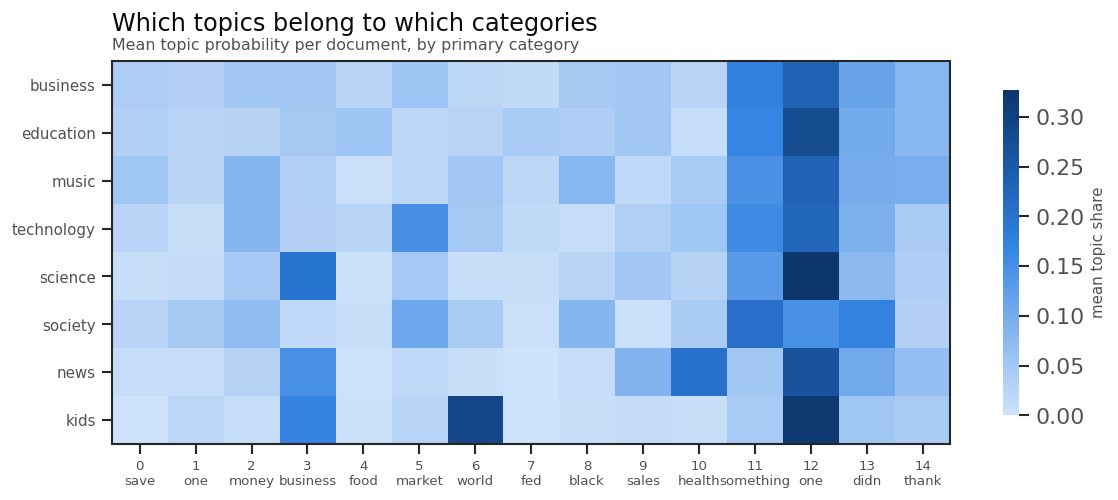

In [9]:
import matplotlib.pyplot as plt
from _viz import sequential_cmap

m = pd.DataFrame(meta[:len(D)])
m = m.assign(**{f"t{i}": D[:, i] for i in range(NUM_TOPICS)})

top_cats = m.category.value_counts().head(8).index.tolist()
mat = (m[m.category.isin(top_cats)]
         .groupby("category")[[f"t{i}" for i in range(NUM_TOPICS)]].mean()
         .loc[top_cats])

fig, ax = plt.subplots(figsize=(10, 4.4))
im = ax.imshow(mat.values, aspect="auto", cmap=sequential_cmap(), vmin=0)
ax.set_xticks(range(NUM_TOPICS))
ax.set_xticklabels([f"{i}\n{topics[i][0][:9]}" for i in range(NUM_TOPICS)],
                   fontsize=8)
ax.set_yticks(range(len(mat)))
ax.set_yticklabels(mat.index, fontsize=9)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("mean topic share", fontsize=9, color=INK_SECONDARY)
cb.outline.set_visible(False)
finish(ax, title="Which topics belong to which categories",
       subtitle="Mean topic probability per document, by primary category")
plt.show()


In [10]:
# The most category-distinctive topic: highest share relative to its own mean.
rel = mat / mat.mean(axis=0)
for cat in mat.index:
    t = int(rel.loc[cat].values.argmax())
    print(f"  {cat:26s} -> topic {t:2d}  ({' '.join(topics[t][:6])})")


  business                   -> topic  4  (food matt music one body restaurant)
  education                  -> topic  4  (food matt music one body restaurant)
  music                      -> topic  8  (black feel women life see also)
  technology                 -> topic  5  (market see back mean last stock)
  science                    -> topic  3  (business company companies businesses industry technology)
  society                    -> topic  8  (black feel women life see also)
  news                       -> topic 10  (health patients care patient public dental)
  kids                       -> topic  6  (world new sure value states give)


## 6.6 Caveats

* **k is a choice, not a finding.** 15 topics because we said 15. Fit several
  values and look at them; there is no "correct" k, and coherence metrics only
  narrow the field.
* **Stopwords shape the result.** The `EXTRA_STOP` list above is doing real work:
  without it, conversational filler dominates every topic. That list is a
  researcher decision and belongs in your write-up.
* **Windows overlap.** `overlap=3` means adjacent documents share turns, so
  documents are not independent. Fine for description, wrong for anything
  inferential.
* **Ads.** Podcast transcripts are full of read advertising, which forms tight,
  high-coherence topics that are about the ad market rather than the show.
* **Two months, 65% coverage.** As everywhere in SPoRC.
